# 2×3 heatmaps for single-point energy and FGW distance

This notebook reads three CSV files with columns:

- `shift_a`
- `shift_b`
- `fgw_distance`
- `single_point_energy`

and generates a publication-style **2×3 heatmap figure**:

- **Top row (a):** relative single-point energy heatmaps, where each system is shifted by its own minimum energy
- **Bottom row (b):** relative FGW distance heatmaps, where each system is shifted by its own minimum FGW distance
- **Columns:** KI/NaCl, GaP/GaAs, GaN/Al$_2$O$_3$

The two rows each use a **shared color scale across the three systems**.
The figure is saved directly as **PDF**.


In [85]:

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colors
from pathlib import Path

# Vector-friendly font embedding
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

# Journal-style global settings
mpl.rcParams.update({
    'font.family': 'Arial',
    'font.size': 8,
    'axes.titlesize': 9,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.major.size': 3.5,
    'ytick.major.size': 3.5,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.01,
})

from matplotlib.colors import LinearSegmentedColormap


In [86]:

# =========================
# User input
# =========================
csv_paths = [
    '../mace_results/KI_NaCl_scf.csv',
    '../mace_results/GaP_GaAs_scf.csv',
    '../mace_results/GaN_Al2O3_scf.csv',
]

column_titles = [
    'KI/NaCl',
    'GaP/GaAs',
    'GaN/Al$_2$O$_3$',
]

output_stem = 'fgw_sp_energy_heatmaps_2x3'



In [87]:
def load_and_prepare(csv_path):
    df = pd.read_csv(csv_path).copy()

    required = ['shift_a', 'shift_b', 'fgw_distance', 'single_point_energy']
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f'{csv_path} is missing required columns: {missing}')

    for col in required:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    df = df.dropna(subset=required).copy()
    if df.empty:
        raise ValueError(f'No valid rows remain after numeric conversion in {csv_path}')

    # Relative quantities used for the two heatmap rows
    df['relative_energy'] = df['single_point_energy'] - df['single_point_energy'].min()
    df['fgw_rel'] = df['fgw_distance'] - df['fgw_distance'].min()

    energy_grid = df.pivot_table(
        index='shift_b', columns='shift_a', values='relative_energy', aggfunc='mean'
    ).sort_index().sort_index(axis=1)

    fgw_grid = df.pivot_table(
        index='shift_b', columns='shift_a', values='fgw_rel', aggfunc='mean'
    ).sort_index().sort_index(axis=1)

    if energy_grid.shape != fgw_grid.shape:
        raise ValueError(
            f'Grid shape mismatch in {csv_path}: energy {energy_grid.shape}, fgw {fgw_grid.shape}'
        )

    return {
        'df': df,
        'energy_grid': energy_grid,
        'fgw_grid': fgw_grid,
        'shape': energy_grid.shape,
    }


def index_ticks(n):
    """
    Return tick positions and labels for an n x n-style grid.
    Labels are 1-based grid indices so 23x23 and 24x24 are shown honestly
    while keeping identical panel sizes.
    """
    if n < 2:
        return [0], ['1']

    mid = (n - 1) / 2
    positions = [0, mid, n - 1]
    labels = ['1', f'{int(round(mid + 1))}', f'{n}']
    return positions, labels


In [88]:
datasets = [load_and_prepare(p) for p in csv_paths]

# Shared color scales within each row
energy_vmin = min(np.nanmin(d['energy_grid'].to_numpy()) for d in datasets)
energy_vmax = max(np.nanmax(d['energy_grid'].to_numpy()) for d in datasets)

fgw_vmin = min(np.nanmin(d['fgw_grid'].to_numpy()) for d in datasets)
fgw_vmax = max(np.nanmax(d['fgw_grid'].to_numpy()) for d in datasets)

print(f'Energy row scale: {energy_vmin:.6f} to {energy_vmax:.6f} eV')
print(f'FGW row scale:    {fgw_vmin:.6f} to {fgw_vmax:.6f}')


Energy row scale: 0.000000 to 0.296631 eV
FGW row scale:    0.000000 to 0.005212


In [89]:
# Quick sanity check
for name, dataset in zip(column_titles, datasets):
    df = dataset['df']
    print(
        name,
        "FGW min ->", f"{df['fgw_distance'].min():.6f}",
        "; relative FGW min ->", f"{df['fgw_rel'].min():.6f}"
    )


KI/NaCl FGW min -> 0.220727 ; relative FGW min -> 0.000000
GaP/GaAs FGW min -> 0.272253 ; relative FGW min -> 0.000000
GaN/Al$_2$O$_3$ FGW min -> 0.242224 ; relative FGW min -> 0.000000


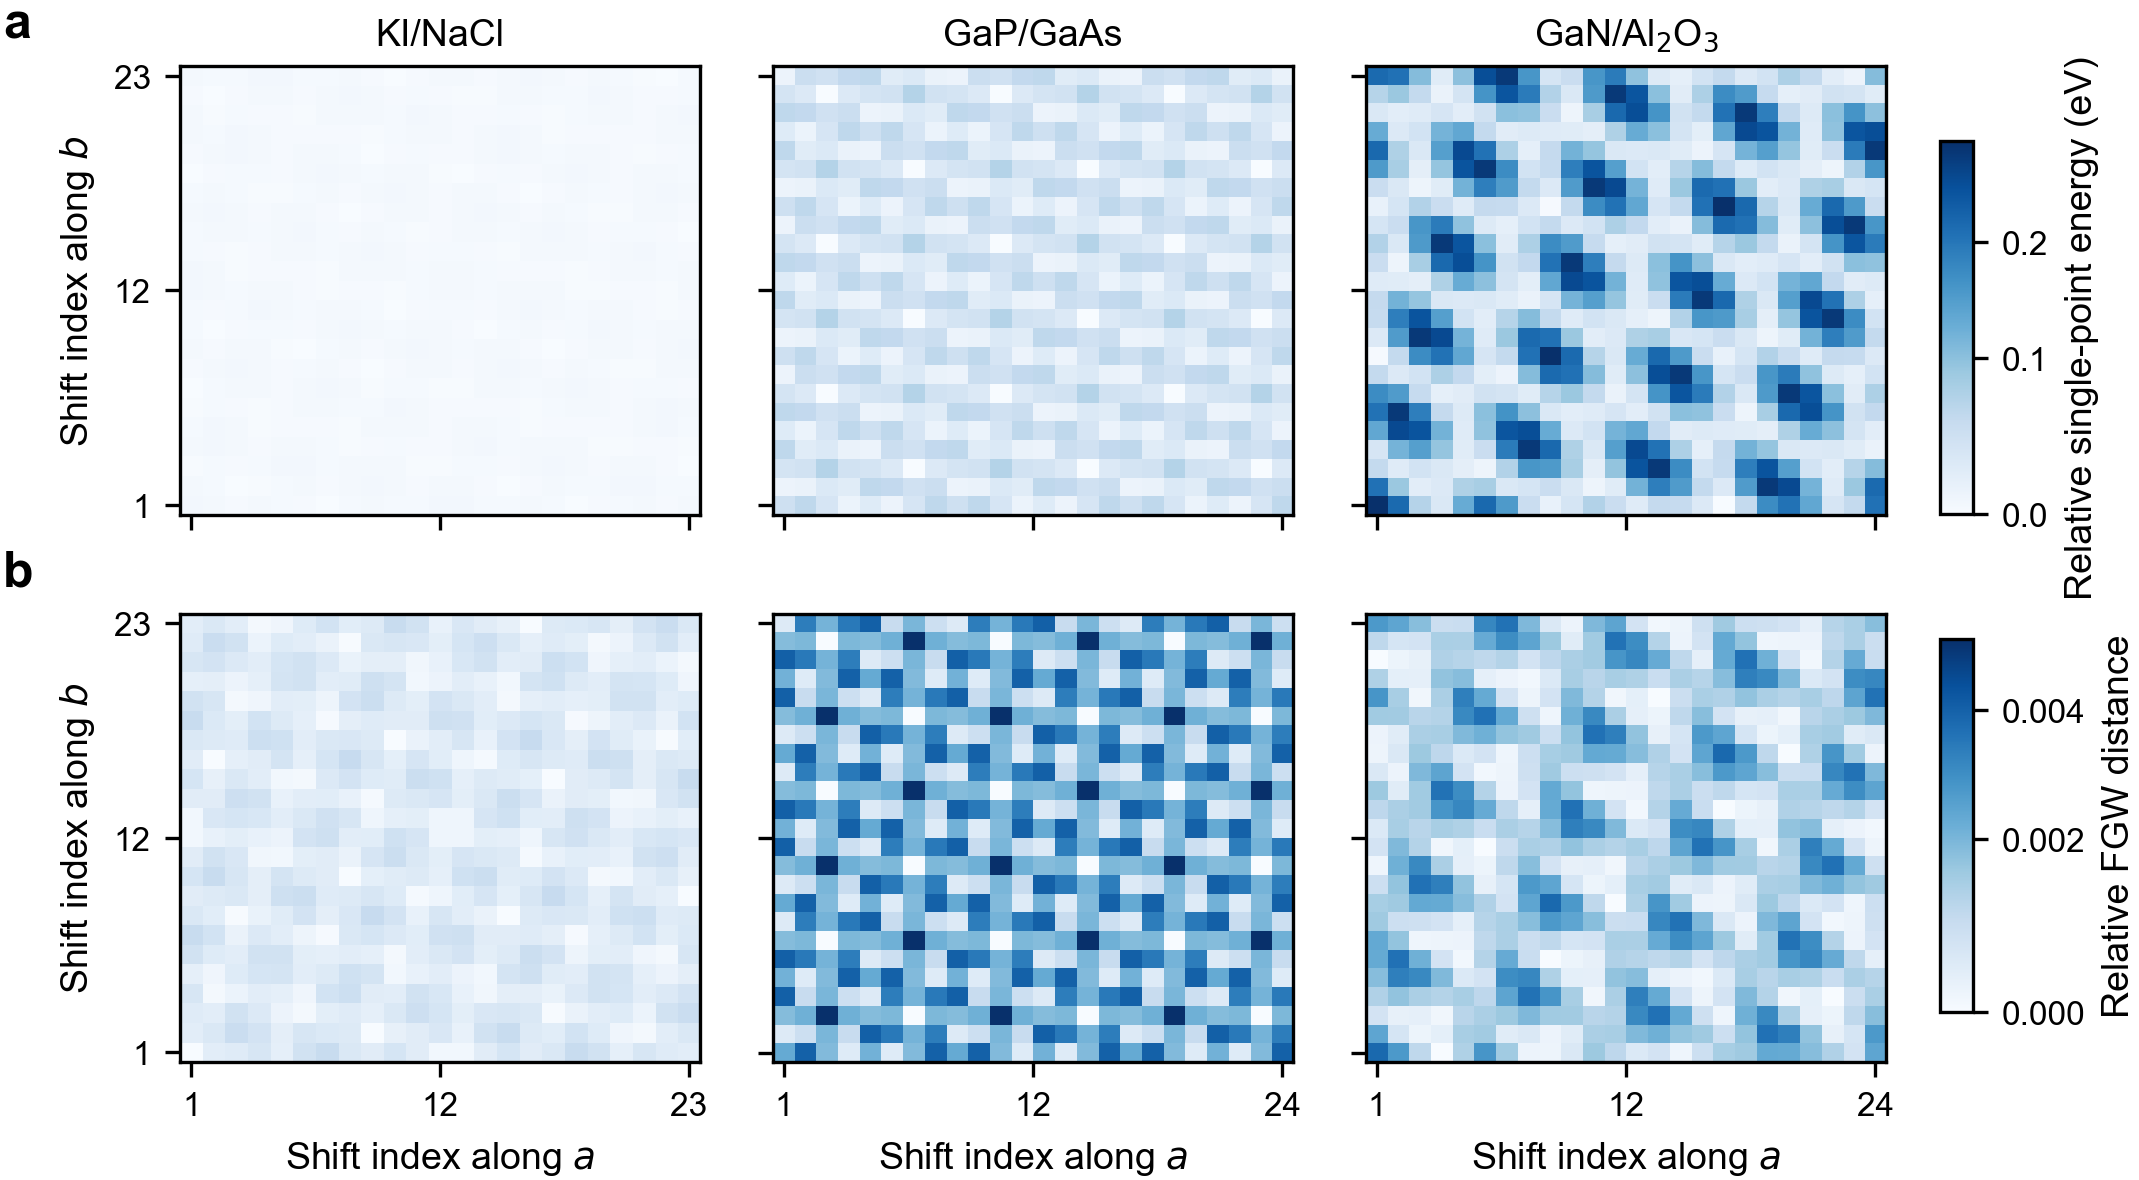

In [90]:

# =========================
# Figure
# =========================
# Double-column width, compact height for a 2×3 layout + right-side vertical colorbars
fig, axes = plt.subplots(
    2, 3,
    figsize=(7.2, 4.15),
    constrained_layout=False
)

def truncate_colormap(cmap_name, minval=0.10, maxval=0.98, n=256):
    base = plt.get_cmap(cmap_name)
    return LinearSegmentedColormap.from_list(
        f"trunc_{cmap_name}",
        base(np.linspace(minval, maxval, n))
    )

# Use one unified high-contrast journal-style blue map for all six panels.
# Truncating the palest end avoids washed-out near-white blocks.
journal_blue = truncate_colormap('Blues', minval=0.0, maxval=1.0)

# Mild power normalization to enhance contrast while preserving row-wise shared scales.
energy_norm = colors.PowerNorm(gamma=0.8, vmin=energy_vmin, vmax=energy_vmax)
fgw_norm = colors.PowerNorm(gamma=0.8, vmin=fgw_vmin, vmax=fgw_vmax)

energy_mappable = None
fgw_mappable = None

for j, (ax, dataset, title) in enumerate(zip(axes[0], datasets, column_titles)):
    grid = dataset['energy_grid']
    nrows, ncols = grid.shape

    im = ax.imshow(
        grid.to_numpy(),
        origin='lower',
        aspect='auto',
        cmap=journal_blue,
        norm=energy_norm,
        interpolation='nearest'
    )
    energy_mappable = im

    xticks, xticklabels = index_ticks(ncols)
    yticks, yticklabels = index_ticks(nrows)

    ax.set_title(title, pad=5)
    ax.set_xticks(xticks)
    ax.set_xticklabels([])
    ax.set_yticks(yticks)
    ax.set_yticklabels(yticklabels)
    ax.tick_params(direction='out', top=False, right=False)

    if j == 0:
        ax.set_ylabel('Shift index along $b$')
    else:
        ax.set_ylabel('')
        ax.set_yticklabels([])

    ax.set_xlabel('')

for j, (ax, dataset) in enumerate(zip(axes[1], datasets)):
    grid = dataset['fgw_grid']
    nrows, ncols = grid.shape

    im = ax.imshow(
        grid.to_numpy(),
        origin='lower',
        aspect='auto',
        cmap=journal_blue,
        norm=fgw_norm,
        interpolation='nearest'
    )
    fgw_mappable = im

    xticks, xticklabels = index_ticks(ncols)
    yticks, yticklabels = index_ticks(nrows)

    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels)
    ax.set_yticks(yticks)
    ax.set_yticklabels(yticklabels)
    ax.tick_params(direction='out', top=False, right=False)

    ax.set_xlabel('Shift index along $a$')
    if j == 0:
        ax.set_ylabel('Shift index along $b$')
    else:
        ax.set_ylabel('')
        ax.set_yticklabels([])

# Row labels: a (top row), b (bottom row)
axes[0, 0].text(
    -0.34, 1.04, 'a',
    transform=axes[0, 0].transAxes,
    fontsize=12, fontweight='bold',
    va='bottom', ha='left'
)
axes[1, 0].text(
    -0.34, 1.04, 'b',
    transform=axes[1, 0].transAxes,
    fontsize=12, fontweight='bold',
    va='bottom', ha='left'
)

# Right-side vertical colorbars, one per row
cax1 = fig.add_axes([0.915, 0.56, 0.015, 0.30])
cbar1 = fig.colorbar(energy_mappable, cax=cax1, orientation='vertical')
cbar1.set_label('Relative single-point energy (eV)')
cbar1.ax.tick_params(direction='out')

cax2 = fig.add_axes([0.915, 0.16, 0.015, 0.30])
cbar2 = fig.colorbar(fgw_mappable, cax=cax2, orientation='vertical')
cbar2.set_label('Relative FGW distance')
cbar2.ax.tick_params(direction='out')

fig.subplots_adjust(
    left=0.10,
    right=0.89,
    bottom=0.12,
    top=0.92,
    wspace=0.14,
    hspace=0.22
)

plt.show()


In [91]:
pdf_path = f'{output_stem}.pdf'

fig.savefig(pdf_path)

print(f'Saved: {pdf_path}')


Saved: fgw_sp_energy_heatmaps_2x3.pdf
